### Implementing the Positional Encoding Function
$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)$$

The division term can be written as:
$$\text{div\_term} = \frac{1}{10000^{\frac{2i}{d_{\text{model}}}}} = 10000^{-\frac{2i}{d_{\text{model}}}}$$

For numerical and code stability, we rewrite the negative exponent fraction using the natural logarithm identity $A^{-B} = e^{-B \cdot \ln(A)}$:
$$10000^{-\frac{2i}{d_{\text{model}}}} = e^{2i \cdot \left(-\frac{\ln(10000)}{d_{\text{model}}}\right)}$$

In [4]:
import numpy as np

def get_positional_encoding(max_seq_len, d_model):

    if d_model % 2 != 0:
        raise ValueError("d_model must be an even number to accommodate sin/cos pairs.")
    
    pos_encoding = np.zeros((max_seq_len, d_model))

    # creating 1D array 0,1,..,max_seq_len-1 and then converts 1D to 2D
    pos = np.arange(max_seq_len)[:, np.newaxis]

    # shape (d_model/2,)
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000)/d_model))

    pos_encoding[:, 0::2] = np.sin(pos * div_term)

    pos_encoding[:, 1::2] = np.cos(pos * div_term)

    return pos_encoding



    

In [5]:
max_len = 50  # Maximum sequence length
d_model = 128 # Embedding dimension (must be even)

positional_encodings = get_positional_encoding(max_len, d_model)

print(f"Shape of generated positional encodings: {positional_encodings.shape}")

Shape of generated positional encodings: (50, 128)


In [7]:
selected_positions = [0, 10, 25]
subset = positional_encodings[selected_positions]

#### Visualization


Heatmap

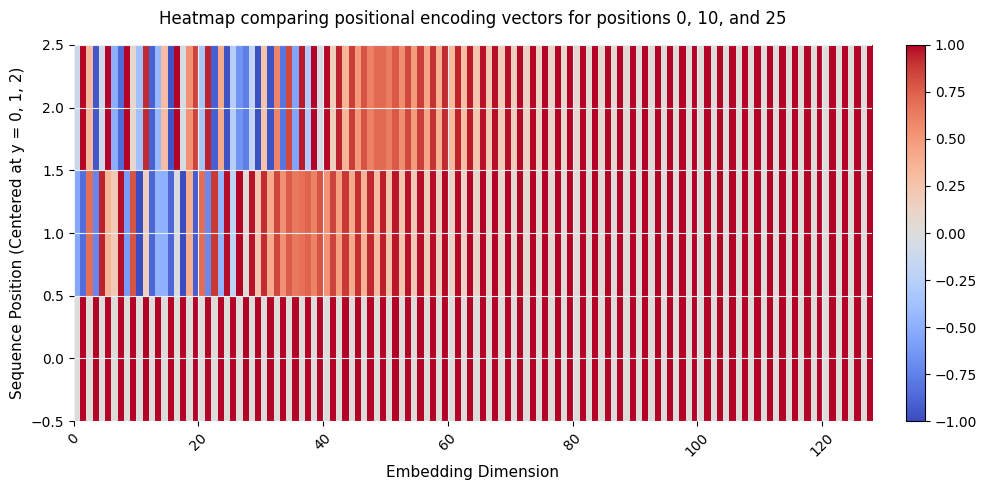

In [8]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10, 5))
# - 'extent' maps the 3x128 array to y-coordinates from -0.5 to 2.5 and x from 0 to 128.
# - 'origin="lower"' puts Row 0 (Position 0) at the bottom, Row 1 (Pos 10) in middle, Row 2 (Pos 25) at top.
im = ax1.imshow(subset, cmap="coolwarm", aspect="auto", extent=[0, d_model, -0.5, 2.5], origin="lower", vmin=-1, vmax=1)
# Colorbar & grids
cbar = fig.colorbar(im, ax=ax1, fraction=0.03, pad=0.04)
ax1.grid(True, which='both', color='#EAF0F6', linestyle='-', linewidth=0.8)
# Styling axes matching reference
ax1.set_yticks([-0.5, 0, 0.5, 1, 1.5, 2, 2.5])
ax1.set_xticks(np.arange(0, 121, 20))
ax1.tick_params(axis='x', rotation=45)
# Label mapping to clarify what each center-row index represents
ax1.set_ylabel("Sequence Position (Centered at y = 0, 1, 2)", fontsize=11)
ax1.set_xlabel("Embedding Dimension", fontsize=11)
ax1.set_title("Heatmap comparing positional encoding vectors for positions 0, 10, and 25", pad=15, fontsize=12)
# Remove outer frame lines (spines) for cleaner look
for spine in ax1.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

Sine/Cosine curves

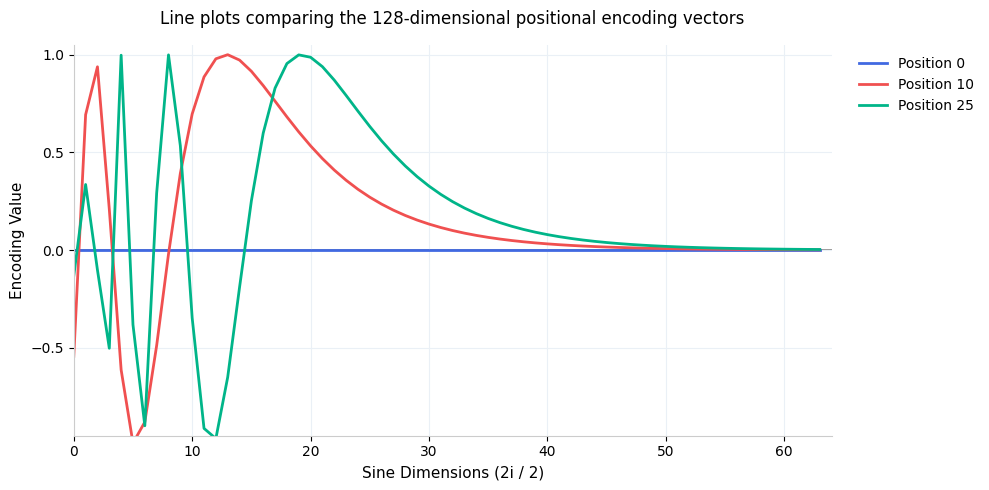

In [9]:
plt.figure(figsize=(10, 5))
# We plot the 64 sine dimensions (indices 0::2) for positions 0, 10, and 25
# This gives the smooth sine wave shapes as shown in the reference image.
x_dims = np.arange(d_model // 2)
plt.plot(x_dims, positional_encodings[0, 0::2], label="Position 0", color="#4169E1", linewidth=2)   # Royal Blue
plt.plot(x_dims, positional_encodings[10, 0::2], label="Position 10", color="#F05050", linewidth=2) # Red/Coral
plt.plot(x_dims, positional_encodings[25, 0::2], label="Position 25", color="#00B589", linewidth=2) # Emerald Green
# Baseline marker y=0
plt.axhline(0, color='#888888', linewidth=1.2, linestyle='-', zorder=1)
# Styling axes matching reference
plt.grid(True, which='both', color='#EAF0F6', linestyle='-', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=10)
plt.yticks([-0.5, 0, 0.5, 1])
plt.xlim(0, 64)
plt.ylim(-0.95, 1.05)
plt.xlabel("Sine Dimensions (2i / 2)", fontsize=11)
plt.ylabel("Encoding Value", fontsize=11)
plt.title("Line plots comparing the 128-dimensional positional encoding vectors", pad=15, fontsize=12)
# Clean up axes border spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#CCCCCC')
plt.gca().spines['bottom'].set_color('#CCCCCC')
plt.tight_layout()
plt.show()